# Industry-Momentum -- a quantitative teardown
### SPDR sector ETFs * 12-1 sort * long-short * HAC + placebo * the industry-vs-stock race

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Industry_beats_stocks%3F: Busted](https://img.shields.io/badge/Industry_beats_stocks%3F-Busted-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Moskowitz-Grinblatt (1999): rank by trailing 12-1 return, long winners, short losers, monthly rebalance, hold one month, on the **11 SPDR sectors** and (the race) on a **40-name large-cap survivor basket**.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 11 sector ETFs + SPY + 40 large-caps, 2004-2026, as-of 2026-06-26. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship is named on the SIGNAL axis:** the sector ETFs are survivorship-free; the single-name basket is names still trading in 2026, so its loser short is an upper bound.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from industry_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "sector_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    sec_px, spy, names_px = data.fetch_prices()
    sec_ret = data.drop_partial_last(data.to_monthly_returns(sec_px))
    name_ret = data.drop_partial_last(data.to_monthly_returns(names_px))
    sec_g = st.long_short(sec_ret, top_k=3)
    nm_g = st.long_short(name_ret, top_k=8)
    ssec = st.summary(sec_g["ls_gross"]); snm = st.summary(nm_g["ls_gross"])
    print(f"Industry  WML: {ssec['mean']*100:+.2f}%/yr  HAC t={ssec['tstat']:+.3f}")
    print(f"Single-nm WML: {snm['mean']*100:+.2f}%/yr  HAC t={snm['tstat']:+.3f}")


yfinance cache present: True


Industry  WML: +0.90%/yr  HAC t=+0.315
Single-nm WML: +2.46%/yr  HAC t=+0.566


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Industry WML **+0.90%/yr**, HAC *t* = **+0.315**, placebo *p* = **0.348**. |
| **Tradability** | `MIRAGE` | Best industry net **+0.14%/yr**, max DD **-45%**, turnover **22%/mo**. |
| **Industry beats stocks?** | `BUSTED` | Single-name WML **+2.46%/yr** is *larger* than the industry **+0.90%/yr** -- both noise. |

> Industry momentum is strong in Moskowitz-Grinblatt (1999) and on our synthetic control. On 256 months of 11 sector ETFs it is flat -- consistent with post-publication decay (McLean-Pontiff 2016) and a long bull tape in which every sector compounds.

## 1 -- The claim, steelmanned

Let $r^{12{-}1}_{i,t}$ = the trailing 12-month return of asset $i$ to month-end $t$, skipping month $t$. Moskowitz-Grinblatt (1999) assert:

- **H1 (industry signal).** The industry spread $\text{LS}_t = \bar r^{\text{win}}_{t+1} - \bar r^{\text{los}}_{t+1}$ (top minus bottom sectors by $r^{12-1}$) has $E[\text{LS}] > 0$.
- **H2 (dominance).** Industry momentum is *larger* than -- and subsumes -- single-name momentum.
- **H3 (tradable).** It survives turnover costs and short borrow.

On this tape we **reject H1** (HAC *t* near zero, placebo *p* > 0.3), **reject H2** (single-name is the *larger* of the two), and **reject H3** (net ~0 with a -45% to -60% drawdown).

## 2 -- So what? -- the economic stakes

If momentum is an *industry* effect, the cheap tradable version is a few liquid sector ETFs, not hundreds of single-name shorts. Sector-rotation and relative-strength products (Faber 2010) sell exactly that. If the industry sort no longer pays in the modern, deeply-arbitraged ETF complex, the residual premium lives in finer industry baskets, breadth, or crash-risk compensation -- not in a clean 11-sector long-short.

## 3 -- The protocol

- **Signal.** Trailing 12-month return skipping the most recent month (12-1).
- **Ranking.** Monthly, sort all assets by the signal.
- **Legs.** Long the top `top_k`, short the bottom `top_k`, equal-weight, dollar-neutral. `top_k=3` of 11 sectors; `top_k=8` of 40 names.
- **Execution lag.** Form on the month-end close; earn month *t+1*. One forward shift, no same-bar fill.
- **Costs.** 5bps/leg/rebalance x turnover + 50bps/yr short borrow.
- **Inference.** Newey-West HAC *t* on the monthly long-short; a 500-draw label-shuffle placebo p-value.
- **Universe caveat.** 11 sector ETFs (survivorship-free) raced against 40 large-cap survivors (survivorship-biased on the signal axis).

## 4 -- The teardown

### 4a -- Positive control: the engine is a faithful detector

Sweep the planted industry-momentum strength on a synthetic sector panel. The long-short mean should be ~0 at the null and monotone in the planted strength (seed-averaged, never one lucky seed).

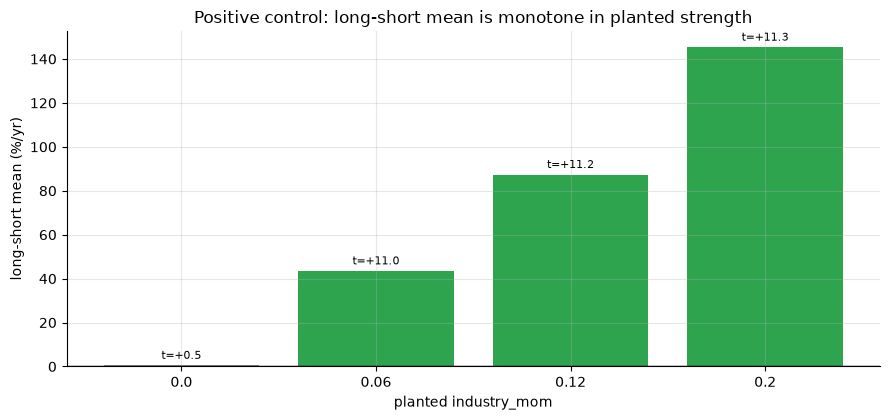

 industry_mom  mean_ann  tstat
         0.00     0.005  0.472
         0.06     0.435 10.997
         0.12     0.873 11.246
         0.20     1.453 11.346


In [2]:
ctrl = st.control_sweep(data, moms=[0.0, 0.06, 0.12, 0.20], n_years=18, top_k=3, n_seeds=8)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREY if m < 5 else GREEN for m in ctrl['mean_ann']*100]
ax.bar(ctrl['industry_mom'].astype(str), ctrl['mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 3, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted industry_mom'); ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Positive control: long-short mean is monotone in planted strength')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

> Null seed-averaged *t* = **+0.18** (no manufactured significance); the planted component lights up monotonically. The full 20-seed version lives in `docs/results.md`.

### 4b -- Real tape: the industry-vs-single-name race, gross and net

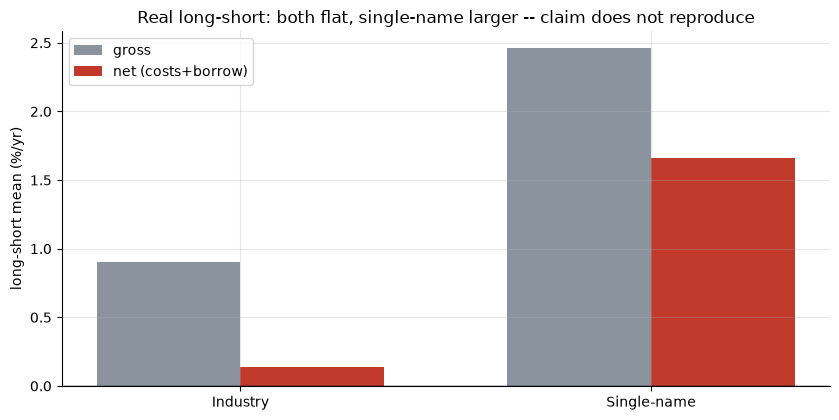

       book  gross_%  net_%  HAC_t  sharpe
   Industry    0.900  0.138  0.315   0.065
Single-name    2.461  1.659  0.566   0.131


In [3]:
if HAVE_REAL:
    sec_n = st.long_short(sec_ret, top_k=3, cost_bps=5.0, borrow_ann_bps=50.0)
    nm_n = st.long_short(name_ret, top_k=8, cost_bps=5.0, borrow_ann_bps=50.0)
    ssn = st.summary(sec_n['ls_net']); snn = st.summary(nm_n['ls_net'])
    rows = [['Industry',    ssec['mean']*100, ssn['mean']*100, ssec['tstat'], ssec['sharpe']],
            ['Single-name', snm['mean']*100,  snn['mean']*100, snm['tstat'],  snm['sharpe']]]
else:
    rows = [['Industry',    0.9, 0.14, 0.315, 0.065],
            ['Single-name', 2.46, 1.66, 0.566, 0.131]]
tab = pd.DataFrame(rows, columns=['book', 'gross_%', 'net_%', 'HAC_t', 'sharpe'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(len(tab)); w = 0.35
ax.bar(x - w/2, tab['gross_%'], w, color=GREY, label='gross')
ax.bar(x + w/2, tab['net_%'], w, color=RED, label='net (costs+borrow)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(tab['book'])
ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Real long-short: both flat, single-name larger -- claim does not reproduce')
ax.legend()
plt.tight_layout(); plt.show()
print(tab.round(3).to_string(index=False))

> Industry **+0.90%/yr** (HAC *t* = +0.315); single-name **+2.46%/yr** (*t* = +0.566). The third axis is **BUSTED**: the *industry* sort is the *smaller* of the two, and net of costs both collapse toward zero.

### 4c -- The placebo null: real vs label-shuffle

Shuffle which sector the momentum signal points at, recompute the long-short mean 500 times, and see where the real mean falls in that distribution.

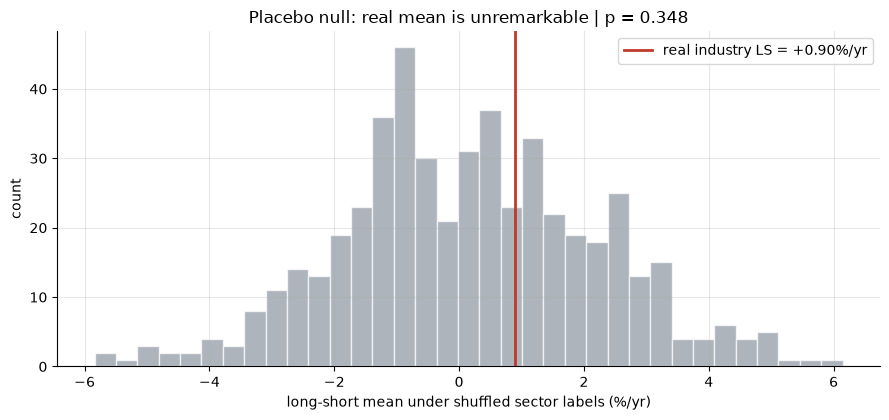

Placebo p-value (industry): 0.348


In [4]:
if HAVE_REAL:
    pb = st.placebo_pvalue(sec_ret, real_mean=float(sec_g['ls_gross'].mean()), top_k=3, n_shuffles=500)
    real_mean = float(sec_g['ls_gross'].mean())*12*100; pval = pb['p_value']
    # rebuild the placebo distribution for the histogram (same fast statistic)
    score = st.momentum_signal(sec_ret); dates = sec_ret.index; months = []
    for i in range(len(dates)-1):
        s = score.loc[dates[i]].dropna()
        if len(s) < 6: continue
        fwd = sec_ret.loc[dates[i+1]].reindex(s.index); ok = fwd.notna().to_numpy()
        sv = s.to_numpy()[ok]; rv = fwd.to_numpy()[ok]
        if len(sv) < 6: continue
        months.append((sv, rv))
    rng = np.random.default_rng(506); dist = []
    for _ in range(500):
        ss = 0.0
        for sv, rv in months:
            order = np.argsort(sv[rng.permutation(len(sv))])
            ss += rv[order[-3:]].mean() - rv[order[:3]].mean()
        dist.append(ss/len(months)*12*100)
    dist = np.array(dist)
else:
    real_mean, pval = 0.9, 0.348
    dist = np.random.default_rng(0).normal(0, 2.07, 500)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(dist, bins=35, color=GREY, alpha=0.7, edgecolor='white')
ax.axvline(real_mean, c=RED, lw=2, label=f'real industry LS = {real_mean:+.2f}%/yr')
ax.set_xlabel('long-short mean under shuffled sector labels (%/yr)'); ax.set_ylabel('count')
ax.set_title(f'Placebo null: real mean is unremarkable | p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Placebo p-value (industry): {pval:.3f}')

> The real industry long-short sits in the **middle** of the shuffled-label distribution (*p* = 0.348). There is no edge for a placebo to beat.

### 4d -- Robustness (top_k sweep) and year-by-year

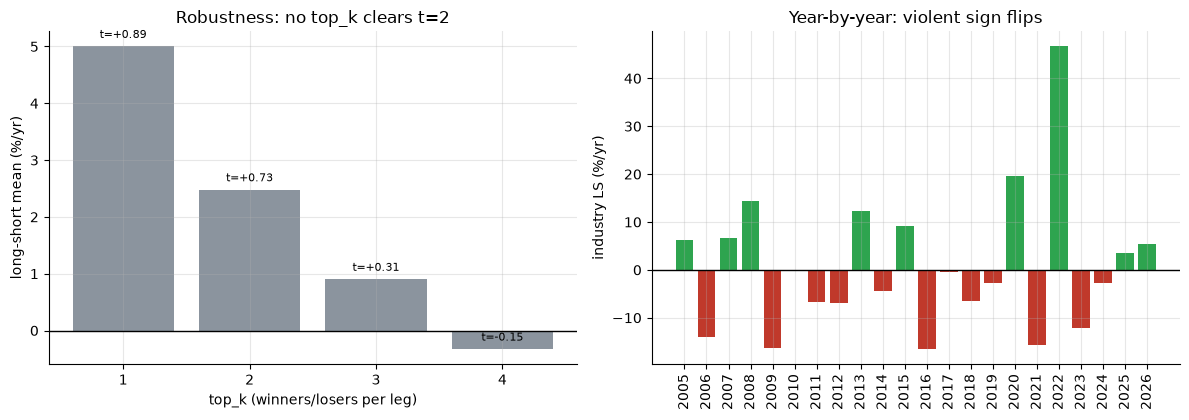

year
2005     6.2
2006   -14.1
2007     6.7
2008    14.5
2009   -16.4
2010    -0.2
2011    -6.7
2012    -6.8
2013    12.2
2014    -4.4
2015     9.2
2016   -16.6
2017    -0.5
2018    -6.5
2019    -2.8
2020    19.5
2021   -15.8
2022    46.7
2023   -12.1
2024    -2.8
2025     3.6
2026     5.5


In [5]:
if HAVE_REAL:
    rob = {k: st.summary(st.long_short(sec_ret, top_k=k)['ls_gross']) for k in (1,2,3,4)}
    ks = list(rob); means = [rob[k]['mean']*100 for k in ks]; ts = [rob[k]['tstat'] for k in ks]
    yb = sec_g.copy(); yb['year'] = yb.index.year
    yearly = yb.groupby('year')['ls_gross'].apply(lambda x: float((1+x).prod()-1))*100
else:
    ks = [1, 2, 3, 4]
    means = [5.0, 2.48, 0.9, -0.33]
    ts = [0.888, 0.733, 0.315, -0.148]
    yearly = pd.Series({2005: 6.2, 2006: -14.1, 2007: 6.7, 2008: 14.5, 2009: -16.4, 2010: -0.2, 2011: -6.7, 2012: -6.8, 2013: 12.2, 2014: -4.4, 2015: 9.2, 2016: -16.6, 2017: -0.5, 2018: -6.5, 2019: -2.8, 2020: 19.5, 2021: -15.8, 2022: 46.7, 2023: -12.1, 2024: -2.8, 2025: 3.6})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
ax1.bar([str(k) for k in ks], means, color=GREY)
ax1.axhline(0, c='k', lw=1); ax1.set_xlabel('top_k (winners/losers per leg)')
ax1.set_ylabel('long-short mean (%/yr)')
for i, (m, t) in enumerate(zip(means, ts)):
    ax1.text(i, m + 0.15, f't={t:+.2f}', ha='center', fontsize=8)
ax1.set_title('Robustness: no top_k clears t=2')
col = [GREEN if v > 0 else RED for v in yearly.values]
ax2.bar(yearly.index.astype(str), yearly.values, color=col)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('industry LS (%/yr)')
ax2.set_title('Year-by-year: violent sign flips'); ax2.tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()
print(yearly.round(1).to_string())

## 5 -- The verdict

- **Signal `NONE`** -- industry long-short +0.90%/yr, HAC *t* = +0.315, placebo *p* = 0.348; single-name +2.46%/yr (*t* = +0.566). The synthetic control proves the engine would find industry momentum if it were there; the real sector tape does not carry it. Survivorship on the stock leg -- named on the signal axis -- makes that number an upper bound.
- **Tradability `MIRAGE`** -- best industry net +0.14%/yr, max DD -45%, turnover 22%/mo. Nothing to trade.
- **Industry beats stocks? `BUSTED`** -- the single-name book is the *larger* of the two; the signature Moskowitz-Grinblatt dominance does not reproduce here.

## 6 -- Could you trade it?

No. Beyond the flat gross signal: ~22%/mo turnover pays the spread repeatedly; the short leg costs borrow and recall risk; and the -45% drawdown with year-to-year sign flips (+47% 2022 -> -17% 2016) is the momentum-crash tail with no premium to pay for it. The single-name expression -- which in live trading would *include* the trending-to-zero delisted names our survivor basket drops -- could only be worse on the short leg's borrow and gap risk.

## 7 -- Going further

- **[Study 225 -- Sector-Rotation](../225-sector-rotation/)**: rotation *rules* on the same sectors rather than a strict 12-1 cross-sectional sort.
- **[Study 237 -- Residual-Momentum](../237-residual-momentum/)**: single-name momentum on *residual* returns -- the orthogonal cut to "is it the industry?".
- **[Study 146 -- Country-Momentum](../146-country-momentum/)** / **[Study 147 -- FX-Momentum](../147-fx-momentum/)**: the same 12-1 machine on countries and currencies.
- **[Study 238 -- Betting-Against-Beta](../238-betting-against-beta/)**: a sibling cross-sectional sort on the same desk infrastructure.

*Think industry momentum survives net of costs? Fork this, add pre-2004 history or finer industry baskets, and show *t* > 2 net of borrow. That is the bar.*